In [89]:
!pip install biopython pyarrow

In [90]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from Bio import SeqIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix



In [ ]:

human_dna = '../GenDataset/human.txt'
df_human = pd.read_table(human_dna,)  


In [92]:
df_human.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [93]:
print(df_human.isnull().sum())

sequence    0
class       0
dtype: int64


In [94]:
df_human['class'].value_counts()

class
6    1343
4     711
3     672
1     534
0     531
2     349
5     240
Name: count, dtype: int64

Text(0.5, 1.0, 'Class distribution of Chimpanzee DNA')

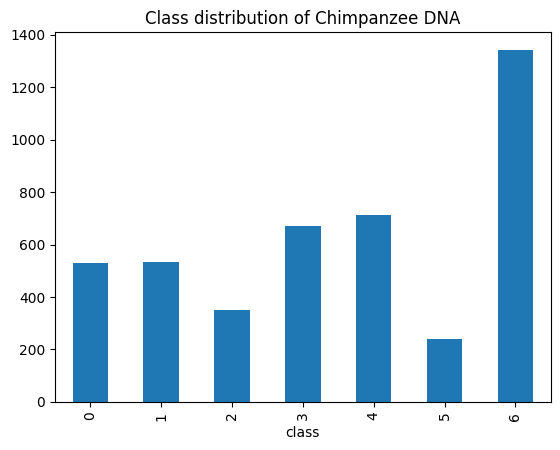

In [95]:
df_human['class'].value_counts().sort_index().plot.bar()
plt.title("Class distribution of Chimpanzee DNA")

Ce tableau est organisé pour faciliter la lecture et l'analyse dans le cadre de ton projet sur la **classification de l'espèce humaine** à partir des **séquences d'ADN**.
| **Famille de gènes**             | **Nombre** | **Étiquette de classe** |
|----------------------------------|------------|--------------------------|
| Récepteurs couplés aux protéines G | 531        | 0                        |
| Tyrosine kinase                  | 534        | 1                        |
| Tyrosine phosphatase             | 349        | 2                        |
| Synthétase                       | 672        | 3                        |
| Synthase                         | 711        | 4                        |
| Canal ionique                    | 240        | 5                        |
| Facteur de transcription         | 1343       | 56                       |


****************************************************************************

| **Famille de gènes**             | **Fonction**                                                                 |
|----------------------------------|------------------------------------------------------------------------------|
| Récepteurs couplés aux protéines G | Transmettent des signaux entre l'extérieur et l'intérieur des cellules.       |
| Tyrosine kinase              | Régulent la croissance cellulaire et les signaux intracellulaires.          |
| Tyrosine phosphatase         | Désactivent les signaux cellulaires en retirant des groupes phosphate.      |
| Synthétase                   | Catalysent la formation de molécules complexes à partir de molécules simples. |
| Synthase                     | Aident à la synthèse de molécules sans utiliser d'énergie (ATP).            |
| Canal ionique                | Régulent le passage des ions (Na+, K+, etc.) à travers les membranes cellulaires. |
| Facteur de transcription     | Contrôlent l'expression des gènes en activant ou réprimant leur transcription. |


In [96]:
# Taille des séquences
df_human['seq_length'] = df_human['sequence'].apply(len)
df_human.head()

,sequence,class,seq_length
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,207
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,681
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1686
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1206
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1437


In [97]:
print(df_human[['seq_length']].describe())


         seq_length
count   4380.000000
mean    1263.598630
std     1280.754087
min        5.000000
25%      405.000000
50%      865.000000
75%     1662.000000
max    18921.000000


<Axes: >

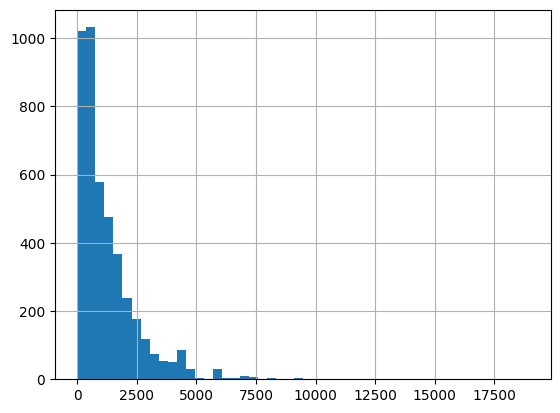

In [98]:
df_human['seq_length'].hist(bins=50)

In [99]:
# Tokenization simple : chaque caractère est un token
# def tokenize_sequence(sequence):
#     return list(sequence)  # Chaque caractère est un token

# df_train['tokens'] = df_train['seq'].apply(tokenize_sequence)
# print(df_train['tokens'].head())


In [100]:
def generate_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# la tokenisation en k-mers
k = 7  
df_human['kmers'] = df_human['sequence'].apply(lambda x: generate_kmers(x, k))
df_human['kmers'].head()


0    [ATGCCCC, TGCCCCA, GCCCCAA, CCCCAAC, CCCAACT, ...
1    [ATGAACG, TGAACGA, GAACGAA, AACGAAA, ACGAAAA, ...
2    [ATGTGTG, TGTGTGG, GTGTGGC, TGTGGCA, GTGGCAT, ...
3    [ATGTGTG, TGTGTGG, GTGTGGC, TGTGGCA, GTGGCAT, ...
4    [ATGCAAC, TGCAACA, GCAACAG, CAACAGC, AACAGCA, ...
Name: kmers, dtype: object

In [101]:
df_human['kmers'].apply(lambda x: [kmer.lower() for kmer in x]).head()

0    [atgcccc, tgcccca, gccccaa, ccccaac, cccaact, ...
1    [atgaacg, tgaacga, gaacgaa, aacgaaa, acgaaaa, ...
2    [atgtgtg, tgtgtgg, gtgtggc, tgtggca, gtggcat, ...
3    [atgtgtg, tgtgtgg, gtgtggc, tgtggca, gtggcat, ...
4    [atgcaac, tgcaaca, gcaacag, caacagc, aacagca, ...
Name: kmers, dtype: object

In [102]:

# Préparer les k-mers comme une chaîne de texte
df_human['kmers_str'] = df_human['kmers'].apply(lambda x: ' '.join(x))
df_human['kmers_str'].head()



0    ATGCCCC TGCCCCA GCCCCAA CCCCAAC CCCAACT CCAACT...
1    ATGAACG TGAACGA GAACGAA AACGAAA ACGAAAA CGAAAA...
2    ATGTGTG TGTGTGG GTGTGGC TGTGGCA GTGGCAT TGGCAT...
3    ATGTGTG TGTGTGG GTGTGGC TGTGGCA GTGGCAT TGGCAT...
4    ATGCAAC TGCAACA GCAACAG CAACAGC AACAGCA ACAGCA...
Name: kmers_str, dtype: object

In [103]:
X_train_text = df_human['kmers_str']
y_train = df_human['class']


X_train, X_test, y_train, y_test = train_test_split(X_train_text, y_train, test_size = 0.20, random_state=42)


In [104]:
# vectorizer = CountVectorizer(ngram_range=(3,6)) # 3-6 mers best result 0.99 
vectorizer = CountVectorizer(ngram_range=(3,7))
# vectorizer = CountVectorizer(ngram_range=(4,4))

X_train = vectorizer.fit_transform(X_train)

# Transformer les données de test avec le même vectorizer
X_test = vectorizer.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(3504, 4354534)
(876, 4354534)


In [105]:
classifier = MultinomialNB(alpha=0.01)
classifier.fit(X_train, y_train)



MultinomialNB(alpha=0.01)

In [106]:
y_pred = classifier.predict(X_test)    

In [107]:
print("Confusion matrix for predictions on test DNA sequence\n")
print(confusion_matrix(y_test, y_pred))
print("\n")
print("Classification report for predictions on test DNA sequence\n")
def get_metrics(y_test, y_predicted):
    accuracy = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, average='weighted')
    recall = recall_score(y_test, y_predicted, average='weighted')
    f1 = f1_score(y_test, y_predicted, average='weighted')
    return accuracy, precision, recall, f1
accuracy, precision, recall, f1 = get_metrics(y_test, y_pred)
print("accuracy = %.5f \nprecision = %.5f \nrecall = %.5f \nf1 = %.5f" % (accuracy, precision, recall, f1))

Confusion matrix for predictions on test DNA sequence

[[101   0   0   0   0   0   1]
 [  0 106   0   0   0   0   0]
 [  0   0  78   0   0   0   0]
 [  0   0   0 124   0   0   1]
 [  1   0   0   0 144   0   4]
 [  0   0   0   0   0  51   0]
 [  1   0   0   0   0   0 264]]


Classification report for predictions on test DNA sequence

accuracy = 0.99087 
precision = 0.99102 
recall = 0.99087 
f1 = 0.99086


In [108]:
219+235

454

# Optimisation avec optuna

In [112]:
import optuna
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train_text = df_human['kmers_str']
y_train = df_human['class']


X_train, X_test, y_train, y_test = train_test_split(X_train_text, y_train, test_size = 0.20, random_state=42)

In [113]:
# Fonction objectif pour Optuna
def objective(trial):
    # 1. Optimiser le ngram_range
    ngram_min = trial.suggest_int("ngram_min", 2, 4)  # Par exemple entre 2 et 4
    ngram_max = trial.suggest_int("ngram_max", ngram_min, 7)  # Max >= Min
    
    # 2. Optimiser l'alpha de MultinomialNB
    alpha = trial.suggest_float("alpha", 0.01, 1.0, log=True)  # Alpha entre 0.01 et 1.0

    # 3. Vectorisation
    vectorizer = CountVectorizer(ngram_range=(ngram_min, ngram_max))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # 4. Entraînement du modèle
    classifier = MultinomialNB(alpha=alpha)
    classifier.fit(X_train_vec, y_train)

    # 5. Évaluation
    y_pred = classifier.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy  # Maximiser l'accuracy

In [ ]:
# Étude Optuna avec parallélisation
study = optuna.create_study(direction="maximize")  # Maximiser l'accuracy

# n_jobs=-1 use avalaible cores ( in 30 cœurs)
study.optimize(objective, n_trials=50, n_jobs=-1)  

# Résultats optimaux
print("Meilleurs paramètres :", study.best_params)
print("Meilleure précision :", study.best_value)


[I 2024-12-11 12:28:08,715] A new study created in memory with name: no-name-9e381907-2ea2-4bf9-99d1-6a6e38f9f8a5
[I 2024-12-11 12:29:48,988] Trial 9 finished with value: 0.9874429223744292 and parameters: {'ngram_min': 4, 'ngram_max': 4, 'alpha': 0.055957400049267386}. Best is trial 9 with value: 0.9874429223744292.
[I 2024-12-11 12:30:42,702] Trial 10 finished with value: 0.9885844748858448 and parameters: {'ngram_min': 3, 'ngram_max': 4, 'alpha': 0.184718956193934}. Best is trial 10 with value: 0.9885844748858448.
[I 2024-12-11 12:32:37,584] Trial 17 finished with value: 0.9885844748858448 and parameters: {'ngram_min': 4, 'ngram_max': 4, 'alpha': 0.10842240608364218}. Best is trial 10 with value: 0.9885844748858448.
[I 2024-12-11 12:38:45,127] Trial 14 finished with value: 0.9885844748858448 and parameters: {'ngram_min': 4, 'ngram_max': 4, 'alpha': 0.21350234481917366}. Best is trial 10 with value: 0.9885844748858448.
[I 2024-12-11 12:39:13,014] Trial 16 finished with value: 0.98630

# BOW

# tfidf